# Sales Analysis of Consumed Kafka Data

### Purpose
This notebook analyzes the processed sales data generated by the Kafka consumer. The goal is to summarize sales activity and visualize total revenue by region.

## 1. Import Libraries
### Purpose
Import the Python libraries used for data analysis and visualization.

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

## 2. Load the Consumed Sales Data
### Purpose
Read the processed output file created by the Kafka consumer.

In [30]:
sales = pd.read_csv("../data/output/consumed_sales_sowers.csv")

## 3. Preview the Data
### Purpose
Display the first few records to verify that the data loaded correctly.

In [31]:
sales.head(3)

,order_id,datetime,region_id,currency_code,product_id,unit_price,quantity,is_online,customer_id,payment_method,subtotal,tax_amount,total,_kafka_key,_kafka_partition,_kafka_offset,sowers_sales_level
0,e7324981-a9f0-419f-b708-d0a333451fff,2026-05-04T08:11:00Z,US-TX,USD,PY-STREAM-005,59.99,3,True,CUST-4150,paypal,179.97,14.85,194.82,US-TX,0,0,High
1,d61943e0-f543-4b5f-9c9a-18605ea4cfe5,2026-05-04T08:23:00Z,US-TX,USD,PY-DATA-002,49.99,1,True,CUST-1106,paypal,49.99,4.12,54.11,US-TX,0,1,Standard
2,14da1915-8e74-47be-9e10-f7275d31af46,2026-05-04T08:28:00Z,CA-QC,CAD,PY-NLP-006,54.99,1,True,CUST-2133,paypal,54.99,8.23,63.22,CA-QC,0,2,Standard


## 4. Examine Data Structure
### Purpose
Review column names, data types, and the number of observations.

In [32]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            6 non-null      str    
 1   datetime            6 non-null      str    
 2   region_id           6 non-null      str    
 3   currency_code       6 non-null      str    
 4   product_id          6 non-null      str    
 5   unit_price          6 non-null      float64
 6   quantity            6 non-null      int64  
 7   is_online           6 non-null      bool   
 8   customer_id         6 non-null      str    
 9   payment_method      6 non-null      str    
 10  subtotal            6 non-null      float64
 11  tax_amount          6 non-null      float64
 12  total               6 non-null      float64
 13  _kafka_key          6 non-null      str    
 14  _kafka_partition    6 non-null      int64  
 15  _kafka_offset       6 non-null      int64  
 16  sowers_sales_level  6 n

## 5. Analyze Sales Levels

### Purpose

Examine the distribution of transactions classified as High and Standard.

### Count Transactions by Sales Level

In [41]:
sales["sowers_sales_level"].value_counts()

sowers_sales_level
Standard    5
High        1
Name: count, dtype: int64

### Summary Statistics by Sales Level

In [33]:
sales.groupby("sowers_sales_level")["total"].agg(["count", "sum", "mean", "min", "max"])

,count,sum,mean,min,max
sowers_sales_level,,,,,
High,1,194.82,194.82,194.82,194.82
Standard,5,277.05,55.41,43.19,65.69


### Findings
Most transactions were classified as Standard, while only one transaction was classified as High.

Although there was only one High transaction, it generated $194.82 in revenue, resulting in a much larger average transaction value than the Standard transactions.

## 6. Calculate Revenue by Region

### Purpose

Aggregate total revenue for each sales region.

### Total Revenue by Region

In [38]:
sales.groupby("region_id")["total"].sum()

region_id
CA-ON     50.84
CA-QC     63.22
US-CA     65.69
US-MO     43.19
US-TX    248.93
Name: total, dtype: float64

### Findings

The regional totals show that US-TX generated the greatest amount of
revenue in the sample dataset.

## 7. Visualize Revenue by Region

### Purpose

Create a chart to compare total revenue across regions.

### Total Revenue by Region

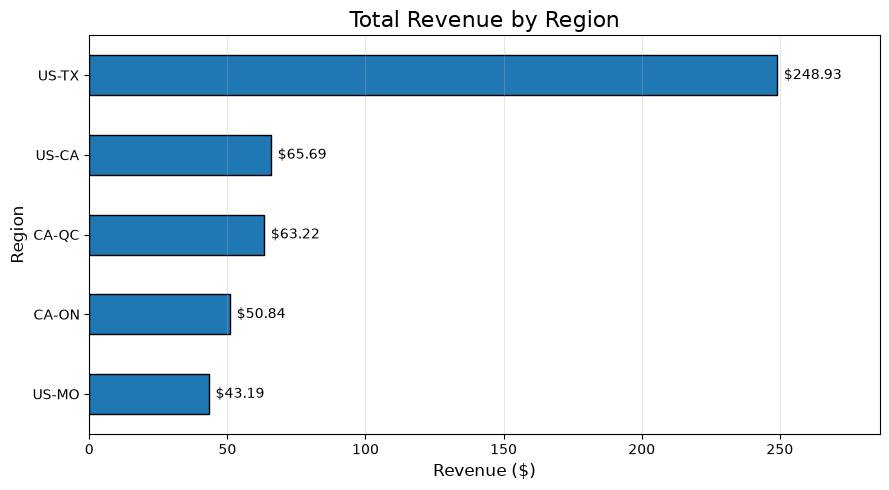

In [39]:
revenue = sales.groupby("region_id")["total"].sum().sort_values()

ax = revenue.plot(kind="barh", figsize=(9, 5), edgecolor="black")

# Add labels with a little padding
for container in ax.containers:
    ax.bar_label(container, fmt="$%.2f", padding=5)

plt.title("Total Revenue by Region", fontsize=16)
plt.xlabel("Revenue ($)", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.grid(axis="x", alpha=0.3)

# Add some extra room on the right
plt.xlim(0, revenue.max() * 1.15)

plt.tight_layout()
plt.show()

### Findings
After analyzing the consumed sales data, I observed that the US-TX region generated the highest revenue. This shows how Kafka streaming data can be transformed into useful business intelligence that highlights differences in regional sales performance.

## 8. Conclusions


### Key Insights

- The Kafka consumer successfully processed the sales records.
- The custom `sowers_sales_level` field classified transactions as
  High or Standard.
- Most transactions were classified as Standard.
- The US-TX region generated the highest total revenue.
- Streaming data can be transformed into meaningful business
  intelligence through analysis and visualization.